# Lab 5 - Greedy Algorithms (Prim and Kruskal)

### Setup and Imports

### Problem Context

Minimum Spanning Tree on connected weighted undirected graphs.

- Prim: expands a tree using the lightest frontier edge.
- Kruskal: takes edges in sorted order and avoids cycles via DSU (Disjoint Set Union).

In [245]:
import math
import random
import heapq
import time
import statistics
from dataclasses import dataclass
import matplotlib.pyplot as plt

### Implementations

In [246]:
class DSU:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n
    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, a, b):
        ra = self.find(a)
        rb = self.find(b)
        if ra == rb:
            return False
        if self.rank[ra] < self.rank[rb]:
            ra, rb = rb, ra
        self.parent[rb] = ra
        if self.rank[ra] == self.rank[rb]:
            self.rank[ra] += 1
        return True

In [247]:
def generate_connected_weighted_graph(n, density=0.25, w_min=1, w_max=100):
    max_edges = n * (n - 1) // 2
    target_edges = max(n - 1, int(density * max_edges))
    target_edges = min(target_edges, max_edges)
    edge_set = set()
    # random spanning tree for guaranteed connectivity
    for v in range(1, n):
        u = random.randint(0, v - 1)
        a, b = (u, v) if u < v else (v, u)
        edge_set.add((a, b))
    # add random extra edges until target reached
    while len(edge_set) < target_edges:
        u = random.randint(0, n - 1)
        v = random.randint(0, n - 1)
        if u == v:
            continue
        a, b = (u, v) if u < v else (v, u)
        edge_set.add((a, b))
    edges = []
    adj = [[] for _ in range(n)]
    for u, v in edge_set:
        w = random.randint(w_min, w_max)
        edges.append((u, v, w))
        adj[u].append((v, w))
        adj[v].append((u, w))
    return edges, adj

In [248]:
def prim_mst(n, adj, start=0):
    visited = [False] * n
    min_heap = [(0, start, -1)]  
    total_weight = 0
    mst_edges = []
    while min_heap and len(mst_edges) < n - 1:
        w, u, parent = heapq.heappop(min_heap)
        if visited[u]:
            continue
        visited[u] = True
        total_weight += w
        if parent != -1:
            mst_edges.append((parent, u, w))
        for v, weight in adj[u]:
            if not visited[v]:
                heapq.heappush(min_heap, (weight, v, u))
    if len(mst_edges) != n - 1:
        raise ValueError("Graph is not connected; MST does not exist.")
    return total_weight, mst_edges

In [249]:
def kruskal_mst(n, edges):
    dsu = DSU(n)
    total_weight = 0
    mst_edges = []
    for u, v, w in sorted(edges, key=lambda x: x[2]):
        if dsu.union(u, v):
            mst_edges.append((u, v, w))
            total_weight += w
            if len(mst_edges) == n - 1:
                break
    if len(mst_edges) != n - 1:
        raise ValueError("Graph is not connected; MST does not exist.")
    return total_weight, mst_edges

In [250]:
# correctness check on a small graph
n = 10
edges, adj = generate_connected_weighted_graph(n, density=0.35)
prim_weight, prim_edges = prim_mst(n, adj)
kruskal_weight, kruskal_edges = kruskal_mst(n, edges)
print(f"Prim MST total weight:    {prim_weight}")
print(f"Kruskal MST total weight: {kruskal_weight}")
print("Weights equal:", prim_weight == kruskal_weight)

Prim MST total weight:    214
Kruskal MST total weight: 214
Weights equal: True


### Visualization: How Prim and Kruskal Build the MST

In [251]:
def circular_layout(n, radius=1.0):
    pos = {}
    for i in range(n):
        theta = 2 * math.pi * i / n
        pos[i] = (radius * math.cos(theta), radius * math.sin(theta))
    return pos
def edge_key(u, v):
    return (u, v) if u < v else (v, u)
VIS_STYLE = {
    'bg': '#f6f8ec',
    'edge_light': '#9fb2a0',
    'edge_mst': '#2a9d8f',
    'node_fill': '#2d728f',
    'node_text': '#f7fff7',
    'accent': '#1b4332',
}
def draw_graph_with_mst(n, edges, mst_edges, title):
    pos = circular_layout(n)
    mst_set = {(edge_key(u, v), w) for u, v, w in mst_edges}
    fig, ax = plt.subplots(figsize=(7.5, 7.2), facecolor=VIS_STYLE['bg'])
    ax.set_facecolor(VIS_STYLE['bg'])
    for u, v, w in edges:
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        if (edge_key(u, v), w) in mst_set:
            ax.plot([x1, x2], [y1, y2], color=VIS_STYLE['edge_mst'], linewidth=3.3, alpha=0.95, solid_capstyle='round')
        else:
            ax.plot([x1, x2], [y1, y2], color=VIS_STYLE['edge_light'], linewidth=1.2, alpha=0.38, linestyle='--')
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mx, my, str(w), fontsize=7, color=VIS_STYLE['accent'], alpha=0.75)
    xs = [pos[i][0] for i in range(n)]
    ys = [pos[i][1] for i in range(n)]
    ax.scatter(xs, ys, s=260, color=VIS_STYLE['node_fill'], edgecolors='#f1f7ed', linewidths=2.0, zorder=3)
    for i in range(n):
        ax.text(pos[i][0], pos[i][1], str(i), fontsize=9, fontweight='bold', ha='center', va='center', color=VIS_STYLE['node_text'], zorder=4)
    ax.set_title(title, fontsize=13, fontweight='bold', color=VIS_STYLE['accent'])
    ax.axis('off')
    plt.tight_layout()
    plt.show()
def plot_cumulative_trace(prim_edges, kruskal_edges):
    prim_cum = []
    total = 0
    for _, _, w in prim_edges:
        total += w
        prim_cum.append(total)
    kr_cum = []
    total = 0
    for _, _, w in kruskal_edges:
        total += w
        kr_cum.append(total)
    x1 = list(range(1, len(prim_cum) + 1))
    x2 = list(range(1, len(kr_cum) + 1))
    fig, ax = plt.subplots(figsize=(8.6, 4.6), facecolor=VIS_STYLE['bg'])
    ax.set_facecolor(VIS_STYLE['bg'])
    ax.plot(x1, prim_cum, marker='o', color='#264653', linewidth=2.4, label='Prim path')
    ax.plot(x2, kr_cum, marker='D', color='#e76f51', linewidth=2.4, label='Kruskal path')
    ax.set_xlabel('Accepted edge index')
    ax.set_ylabel('Cumulative MST weight')
    ax.set_title('MST growth signature: Prim vs Kruskal', fontsize=12.5, fontweight='bold')
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.22, linestyle=':')
    for spine in ax.spines.values():
        spine.set_color('#90a955')
    plt.tight_layout()
    plt.show()
def plot_mst_steps(n, edges, accepted_edges, algo_name):
    pos = circular_layout(n)
    cols = 3
    rows = (len(accepted_edges) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 4.0 * rows), facecolor=VIS_STYLE['bg'])
    axes = axes.ravel() if hasattr(axes, "ravel") else [axes]
    for idx, ax in enumerate(axes):
        ax.set_facecolor(VIS_STYLE['bg'])
        if idx >= len(accepted_edges):
            ax.axis("off")
            continue
        chosen = accepted_edges[: idx + 1]
        chosen_map = {(edge_key(u, v), w) for u, v, w in chosen}
        for u, v, w in edges:
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            if (edge_key(u, v), w) in chosen_map:
                ax.plot([x1, x2], [y1, y2], color=VIS_STYLE['edge_mst'], linewidth=3.0, alpha=0.95, solid_capstyle='round')
            else:
                ax.plot([x1, x2], [y1, y2], color=VIS_STYLE['edge_light'], linewidth=1.0, alpha=0.25, linestyle='--')
        xs = [pos[i][0] for i in range(n)]
        ys = [pos[i][1] for i in range(n)]
        ax.scatter(xs, ys, s=210, color=VIS_STYLE['node_fill'], edgecolors='#f1f7ed', linewidths=1.6, zorder=3)
        for i in range(n):
            ax.text(pos[i][0], pos[i][1], str(i), fontsize=8.5, fontweight='bold', ha='center', va='center', color=VIS_STYLE['node_text'], zorder=4)
        cum = sum(w for _, _, w in chosen)
        ax.set_title(f"{algo_name} | step {idx + 1} | sum={cum}", fontsize=10.2, color=VIS_STYLE['accent'])
        ax.axis("off")
    plt.suptitle(f"{algo_name}: construction storyboard", y=1.02, fontsize=14, fontweight='bold', color=VIS_STYLE['accent'])
    plt.tight_layout()
    plt.show()

Prim total: 56
Kruskal total: 56
Same MST weight: True
Generated graph: nodes=8, edges=12


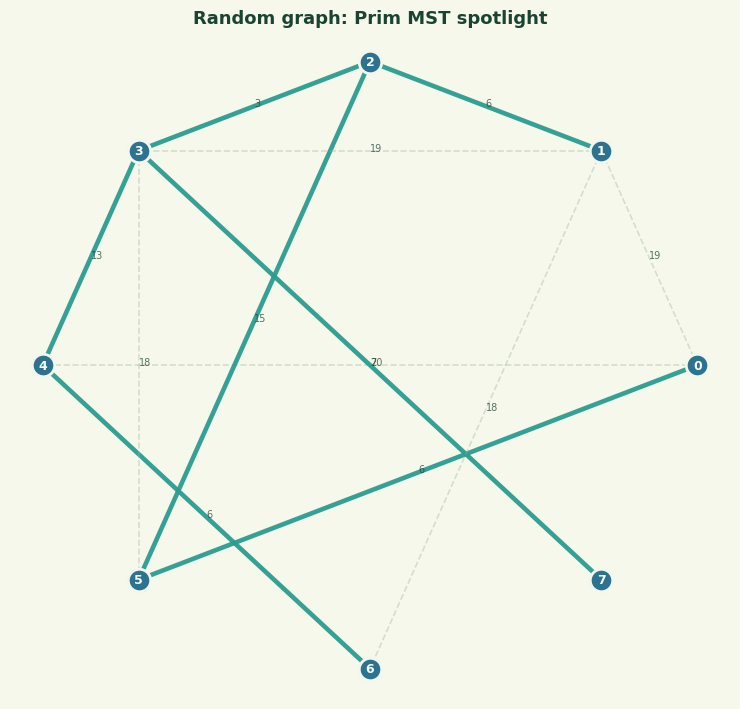

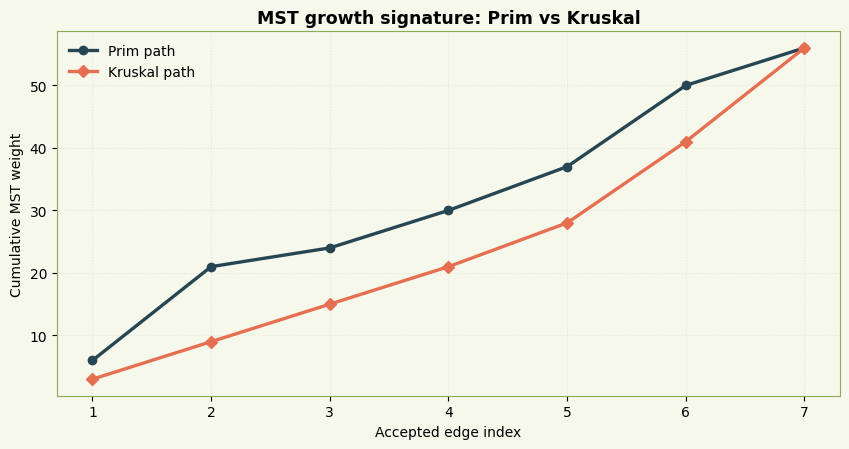

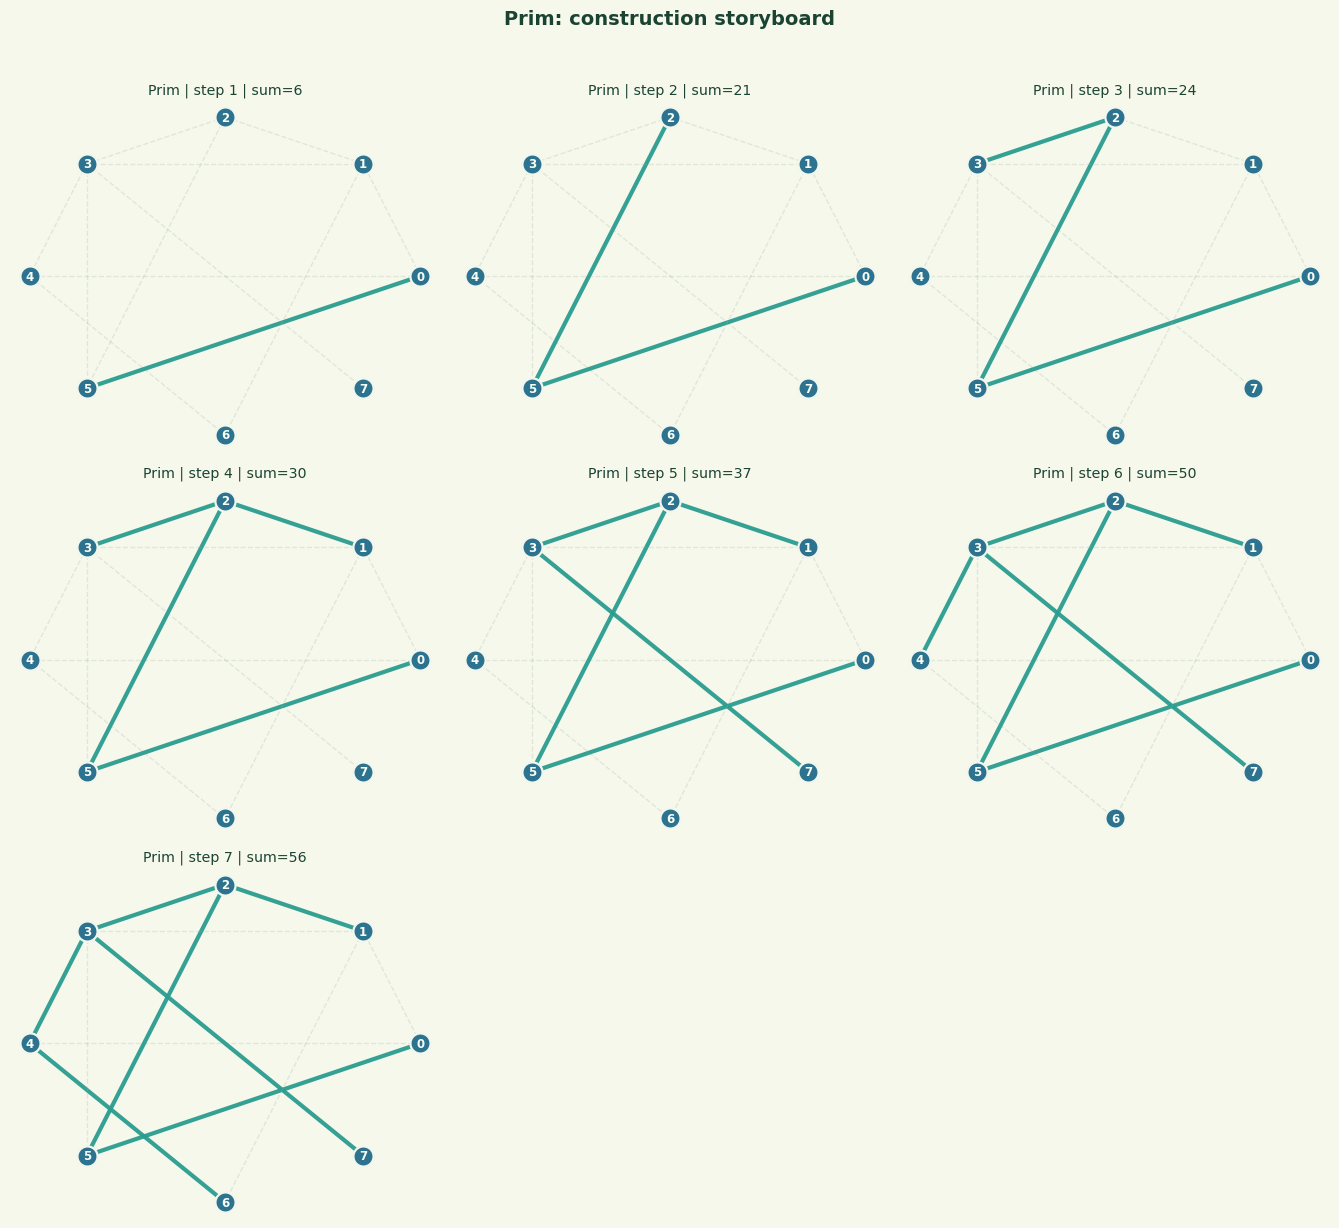

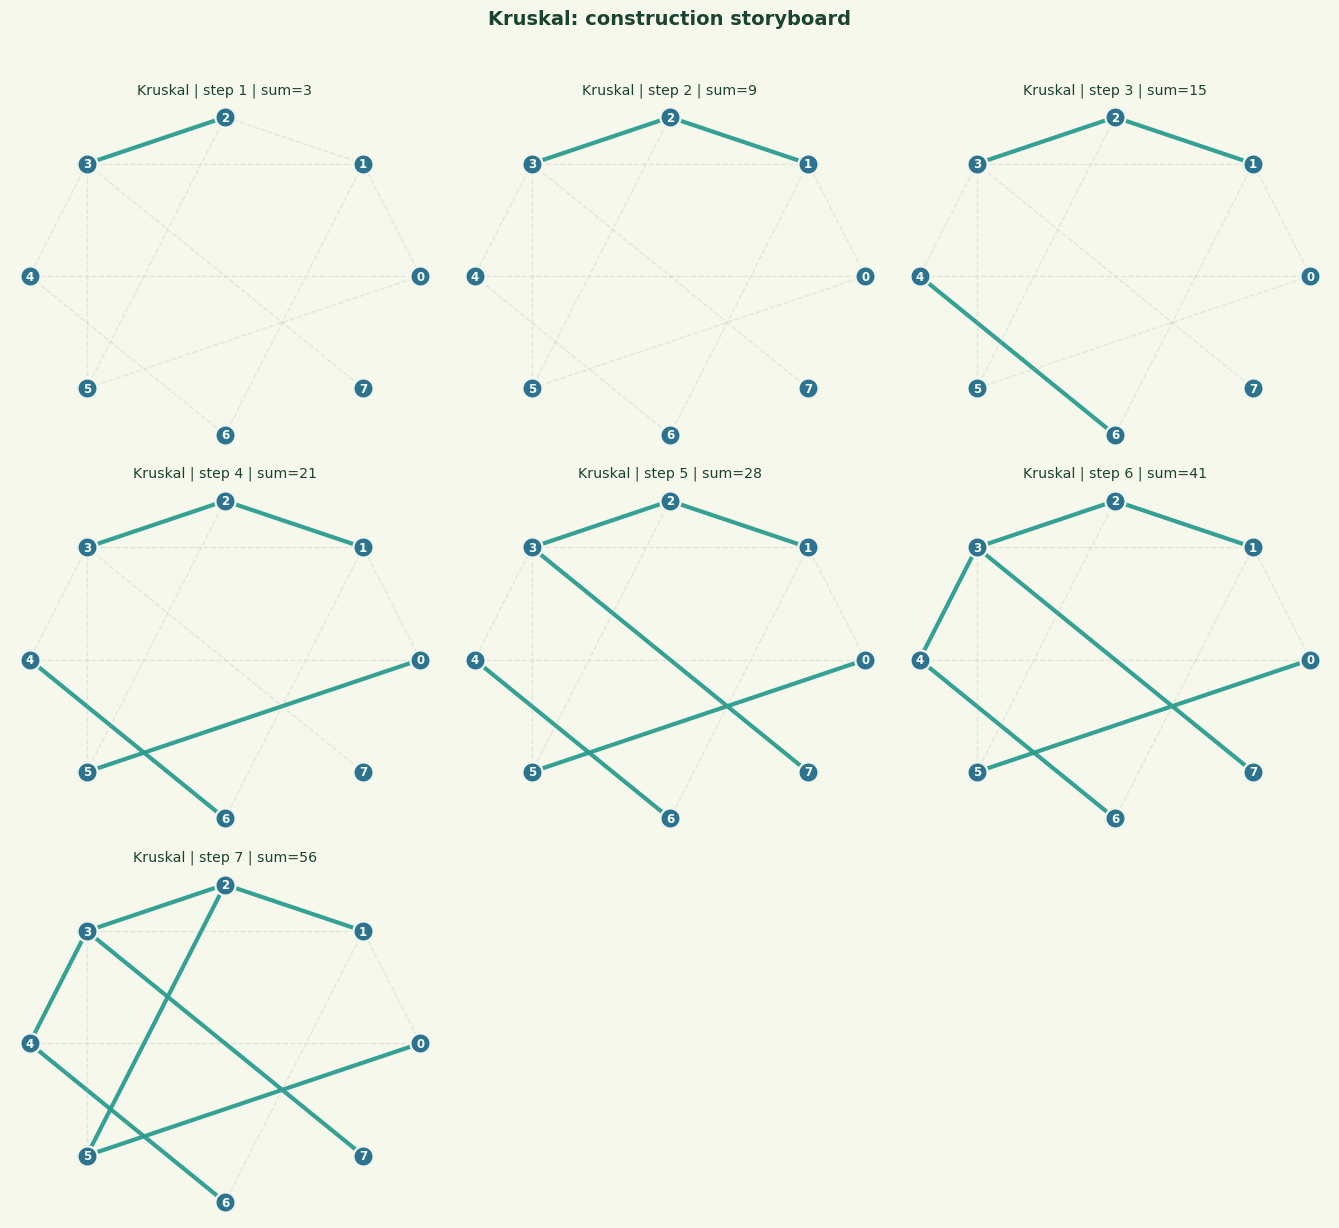

In [252]:
# Random graph to visualize edge-acceptance order
n_demo_vis = 8
edges_vis, adj_demo_vis = generate_connected_weighted_graph(
    n_demo_vis, density=0.45, w_min=1, w_max=20
)
prim_total_vis, prim_edges_vis = prim_mst(n_demo_vis, adj_demo_vis)
kr_total_vis, kr_edges_vis = kruskal_mst(n_demo_vis, edges_vis)
print(f"Prim total: {prim_total_vis}")
print(f"Kruskal total: {kr_total_vis}")
print("Same MST weight:", prim_total_vis == kr_total_vis)
print(f"Generated graph: nodes={n_demo_vis}, edges={len(edges_vis)}")
draw_graph_with_mst(n_demo_vis, edges_vis, prim_edges_vis, "Random graph: Prim MST spotlight")
plot_cumulative_trace(prim_edges_vis, kr_edges_vis)
plot_mst_steps(n_demo_vis, edges_vis, prim_edges_vis, "Prim")
plot_mst_steps(n_demo_vis, edges_vis, kr_edges_vis, "Kruskal")

### Empirical Analysis and Plots

In [253]:
@dataclass
class BenchmarkRow:
    n: int
    edges: int
    density: float
    prim_s: float
    kruskal_s: float
    speedup_kruskal_over_prim: float
    same_weight: bool

In [254]:
def time_function(func, *args, repeats=5):
    timings = []
    result = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        result = func(*args)
        t1 = time.perf_counter()
        timings.append(t1 - t0)
    return statistics.mean(timings), result
def benchmark_mst(node_sizes, density, repeats=5):
    rows = []
    for n in node_sizes:
        edges, adj = generate_connected_weighted_graph(n, density=density)
        prim_time, prim_result = time_function(prim_mst, n, adj, repeats=repeats)
        kr_time, kr_result = time_function(kruskal_mst, n, edges, repeats=repeats)
        prim_weight = prim_result[0]
        kr_weight = kr_result[0]
        rows.append(BenchmarkRow(
            n=n,
            edges=len(edges),
            density=density,
            prim_s=prim_time,
            kruskal_s=kr_time,
            speedup_kruskal_over_prim=(prim_time / kr_time) if kr_time > 0 else float('inf'),
            same_weight=(prim_weight == kr_weight),
        ))
    return rows

In [255]:
node_sizes = [20, 40, 60, 80, 100, 120, 140, 160, 200, 240, 280, 320]
rows_sparse = benchmark_mst(node_sizes=node_sizes, density=0.15, repeats=5)
rows_dense = benchmark_mst(node_sizes=node_sizes, density=0.60, repeats=5)

In [256]:
def print_table(rows, title):
    print(title)
    print("-" * len(title))
    print(f"{'n':>4} {'edges':>8} {'Prim (s)':>12} {'Kruskal (s)':>12} {'Prim/Kruskal':>14} {'same MST':>10}")
    for r in rows:
        print(f"{r.n:>4} {r.edges:>8} {r.prim_s:>12.6f} {r.kruskal_s:>12.6f} {r.speedup_kruskal_over_prim:>14.3f} {str(r.same_weight):>10}")
print_table(rows_sparse, "Sparse Graphs (density=0.15)")
print()
print_table(rows_dense, "Dense Graphs (density=0.60)")

Sparse Graphs (density=0.15)
----------------------------
   n    edges     Prim (s)  Kruskal (s)   Prim/Kruskal   same MST
  20       28     0.000027     0.000028          0.963       True
  40      117     0.000116     0.000084          1.380       True
  60      265     0.000205     0.000122          1.683       True
  80      474     0.001496     0.000218          6.850       True
 100      742     0.000605     0.000378          1.600       True
 120     1071     0.000894     0.000317          2.816       True
 140     1459     0.000486     0.000440          1.104       True
 160     1908     0.001870     0.001159          1.613       True
 200     2985     0.001840     0.001058          1.739       True
 240     4302     0.002277     0.001207          1.887       True
 280     5859     0.004947     0.003609          1.371       True
 320     7656     0.005125     0.002208          2.322       True

Dense Graphs (density=0.60)
---------------------------
   n    edges     Prim (s) 

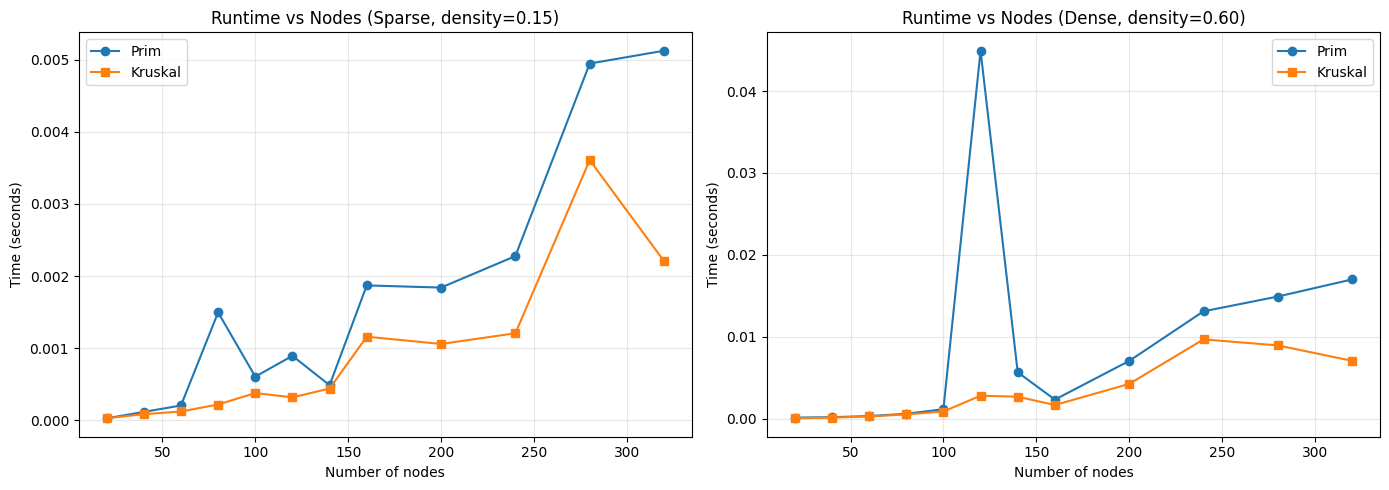

In [257]:
def extract_xy(rows):
    x = [r.n for r in rows]
    y_prim = [r.prim_s for r in rows]
    y_kruskal = [r.kruskal_s for r in rows]
    return x, y_prim, y_kruskal
x_s, prim_s, kr_s = extract_xy(rows_sparse)
x_d, prim_d, kr_d = extract_xy(rows_dense)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(x_s, prim_s, marker='o', label='Prim')
axes[0].plot(x_s, kr_s, marker='s', label='Kruskal')
axes[0].set_title('Runtime vs Nodes (Sparse, density=0.15)')
axes[0].set_xlabel('Number of nodes')
axes[0].set_ylabel('Time (seconds)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[1].plot(x_d, prim_d, marker='o', label='Prim')
axes[1].plot(x_d, kr_d, marker='s', label='Kruskal')
axes[1].set_title('Runtime vs Nodes (Dense, density=0.60)')
axes[1].set_xlabel('Number of nodes')
axes[1].set_ylabel('Time (seconds)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

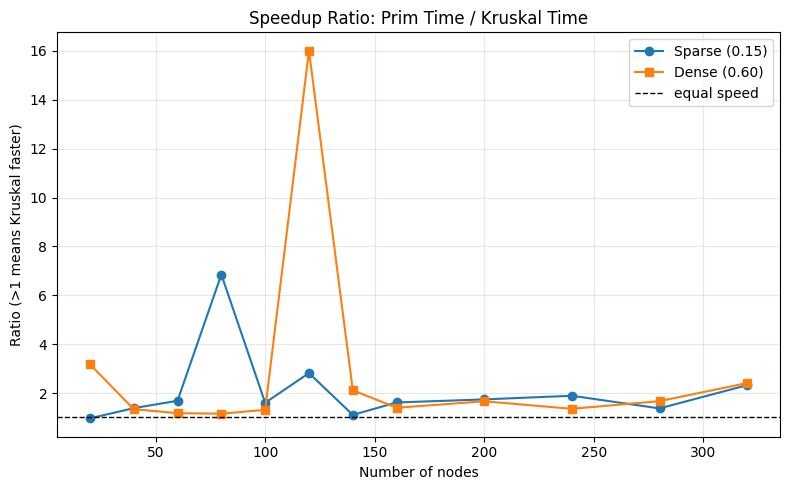

In [258]:
# Graphical presentation of speedup factor Prim/Kruskal
speed_sparse = [r.speedup_kruskal_over_prim for r in rows_sparse]
speed_dense = [r.speedup_kruskal_over_prim for r in rows_dense]
plt.figure(figsize=(8, 5))
plt.plot(node_sizes, speed_sparse, marker='o', label='Sparse (0.15)')
plt.plot(node_sizes, speed_dense, marker='s', label='Dense (0.60)')
plt.axhline(1.0, color='black', linestyle='--', linewidth=1, label='equal speed')
plt.title('Speedup Ratio: Prim Time / Kruskal Time')
plt.xlabel('Number of nodes')
plt.ylabel('Ratio (>1 means Kruskal faster)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Result Notes

- Correctness check: Prim and Kruskal produce the same MST total weight on every connected graph tested, which confirms that both implementations are solving the same problem correctly.
- The generated graphs are connected and weighted, so an MST always exists and both algorithms can be compared on the same input family.
- The visualization section shows not only the final MST, but also how the tree is built step by step, which makes the greedy choice process easier to understand.
- The cumulative weight plots highlight how the accepted edges grow the MST over time for Prim and Kruskal.
- The runtime experiments compare sparse and dense graphs over increasing node counts, so the results show how graph size and edge density affect performance.
- In these experiments, Kruskal is usually faster on sparse graphs, while Prim can become competitive as the graph gets denser.
- In practice, Kruskal is often more convenient when all edges are available in a list, while Prim is a natural fit for adjacency-list representations.